<a href="https://colab.research.google.com/github/smousavi05/Harvard-EPS-210/blob/main/EPS210_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harvard EPS-210 AI for Earth and Planetary Science

Instructor: Mostafa Mouasvi

# Lab 2: From "Messy" to "AI-Ready"

**Goal:** Gain practical experience with the critical steps of data cleaning, transformation, and feature engineering as outlined in the EPS-AI workflow.


## Activity 1: GPS Data Preparation (30 Minutes)

**Context:** The lecture highlights that dropping missing data destroys spatiotemporal structure, while simple linear interpolation can create "fake physics" (e.g., straight lines in seismic data).

**Goal:** Process a network of GPS stations that suffer from real-world issues: Tectonic trends, Seasonal noise, Equipment Jumps, AND Missing Data Gaps.




**Part 1:** The Setup (Simulating the "Mess")

We generate raw ECEF (Earth-Centered) coordinates for 3 stations. The Target station has a hidden transient signal ([a slow earthquake](https://en.wikipedia.org/wiki/Slow_earthquake)) that is currently buried under noise, a jump, and missing data.

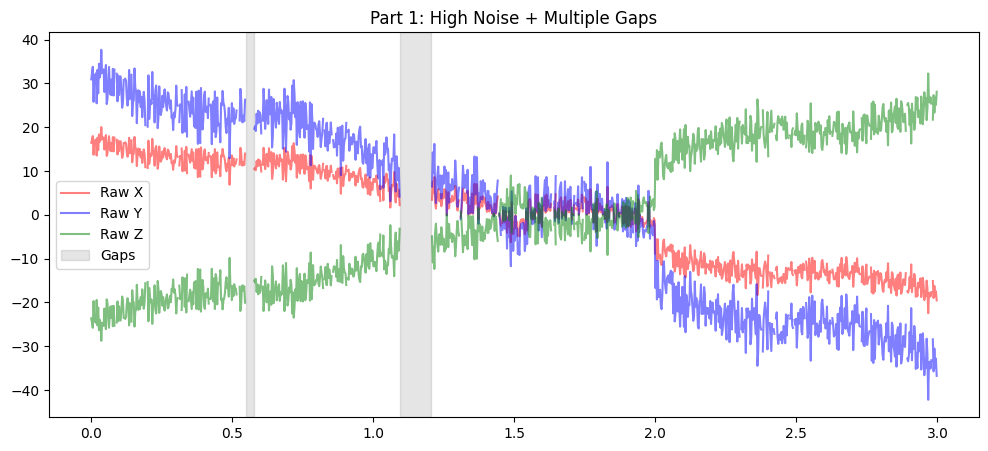

In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

# --- DATA GENERATION ---
np.random.seed(42)
days = np.arange(0, 3 * 365)
years = days / 365.0

# 1. Physics Components (High Noise)
cme_noise = np.random.normal(0, 4.0, len(days))
hidden_event = 12.0 * np.exp(-((years - 1.5)**2) / 0.005)

# 2. Generate Stations
stations = {}
ref_lat, ref_lon = np.radians(34.0), np.radians(-118.0)
R_earth = 6371000

for name in ['Target', 'Ref1', 'Ref2']:
    vel = 25.0 if name == 'Target' else 24.8
    local_noise = np.random.normal(0, 2.5, len(days))

    true_up = (vel * years) + (4.0 * np.sin(2*np.pi*years)) + cme_noise + local_noise

    if name == 'Target':
        true_up += hidden_event
        true_up[years >= 2.0] += 15.0 # Jump

    # Project Up -> Raw XYZ
    raw_x = (R_earth + true_up) * np.cos(ref_lat) * np.cos(ref_lon)
    raw_y = (R_earth + true_up) * np.cos(ref_lat) * np.sin(ref_lon)
    raw_z = (R_earth + true_up) * np.sin(ref_lat)

    df = pd.DataFrame({'Time': years, 'X': raw_x, 'Y': raw_y, 'Z': raw_z})

    df['Ground_Truth_Up'] = true_up

    # --- ADDING GAPS ---
    # 1. Random small dropouts
    df.loc[np.random.rand(len(days)) < 0.05, ['X', 'Y', 'Z']] = np.nan

    if name == 'Target':
        # 2. medium gap (Day 200-215, 10 days)
        df.loc[200:210, ['X', 'Y', 'Z']] = np.nan
        # 3. large gap (Day 400-440, 40 days)
        df.loc[400:440, ['X', 'Y', 'Z']] = np.nan

    stations[name] = df

# --- VISUALIZATION OF RAW DATA ---
target = stations['Target']
plt.figure(figsize=(12, 5))
plt.plot(target['Time'], target['X'] - target['X'].mean(), 'r', alpha=0.5, label='Raw X')
plt.plot(target['Time'], target['Y'] - target['Y'].mean(), 'b', alpha=0.5, label='Raw Y')
plt.plot(target['Time'], target['Z'] - target['Z'].mean(), 'g', alpha=0.5, label='Raw Z')

# Highlight Gaps
plt.axvspan(200/365, 210/365, color='black', alpha=0.1) # Medium
plt.axvspan(400/365, 440/365, color='black', alpha=0.1, label='Gaps')
plt.title("Part 1: High Noise + Multiple Gaps")
plt.legend()
plt.show()

**Part 2:** Coordinate System Transformation

Raw GPS receivers output positions in an X, Y, Z grid with the origin at the center of the Earth.

Problem: If a tectonic plate moves "North," it changes X, Y, and Z simultaneously. An ML model has to learn this complex correlation.

**Solution (Step 1):** Convert raw Earth-Centered Earth-Fixed (ECEF) coordinates into a Local Level frame (NEU). Rotate the data so "North" aligns with the plate motion and "Up" aligns with gravity (and volcanic inflation).




In [127]:
def ecef_to_neu(x, y, z, lat_ref, lon_ref):
    dx, dy, dz = x - x[0], y - y[0], z - z[0]
    sin_lat, cos_lat = np.sin(lat_ref), np.cos(lat_ref)
    sin_lon, cos_lon = np.sin(lon_ref), np.cos(lon_ref)
    u = cos_lat * cos_lon * dx + cos_lat * sin_lon * dy + sin_lat * dz
    return u

# Step 1: XYZ -> Up
for name, df in stations.items():
    df['Up'] = ecef_to_neu(df['X'].values, df['Y'].values, df['Z'].values, ref_lat, ref_lon)

**Part 3:** Remove the trend, seasonal effects, and jumps.

Real GPS data isn't random; it follows this equation:

$$X(t) = \underbrace{v \cdot t + c}_{\text{Tectonic Trend}} + \underbrace{A \sin(\omega t) + B \cos(\omega t)}_{\text{Seasonal Cycle}} + \text{Noise}$$

**1. Trend (Tectonic Plate Motion)**

The Problem: GPS stations are attached to the ground, which is constantly moving due to plate tectonics. This creates a large, dominant linear trend in the data.

Why Remove It: This steady motion is considered "background noise" when looking for transient events. If left in, the trend numerically dominates the data, making it impossible to detect small, temporary displacements.

Note: You only skip this step if your specific research goal is to predict the absolute velocity of the plate.


**2. Seasonal Effects**

The Problem: GPS time series show periodic wobbles (annual and semi-annual cycles) caused by environmental factors like hydrological loading (ground swelling from rain/snow) or thermal expansion.

Why Remove It: These cycles can look very similar to slow slip events (silent earthquakes). Removing them prevents the model from confusing a regular winter rainstorm with a tectonic event.


**3. Jumps (Offsets)**

The Problem: Sudden, instant shifts in the data occur due to non-physical reasons (like replacing a broken antenna) or physical ones (nearby earthquakes).

Why Remove It: These discontinuities break the continuity of the time series. Neural networks, especially Recurrent Neural Networks (LSTMs), struggle to process data with sudden steps and may fail to learn effectively.


In [128]:
# --- FUNCTION: Robust Steps 2, 3, 4 ---
def robust_clean_pipeline(t, signal, jump_times=None):
    valid = ~np.isnan(signal)
    if np.sum(valid) < 10: return signal

    cleaned = signal.copy()

    # Detrend
    poly = np.polyfit(t[valid], signal[valid], 1)
    cleaned -= np.polyval(poly, t)

    # Deseason
    X_season = np.column_stack([np.sin(2*np.pi*t), np.cos(2*np.pi*t)])
    model = LinearRegression().fit(X_season[valid], cleaned[valid])
    cleaned -= model.predict(X_season)

    # Jump Correction
    if jump_times:
        for j_time in jump_times:
            window = 30/365.0
            mask_pre = (t >= j_time - window) & (t < j_time) & valid
            mask_post = (t >= j_time) & (t < j_time + window) & valid
            if np.any(mask_pre) and np.any(mask_post):
                offset = np.mean(cleaned[mask_post]) - np.mean(cleaned[mask_pre])
                cleaned[t >= j_time] -= offset
    return cleaned

# Steps 2-4: Individual Cleaning
jump_log = {'Target': [2.0], 'Ref1': [], 'Ref2': []}
for name, df in stations.items():
    df['Clean_Pre_CME'] = robust_clean_pipeline(df['Time'].values, df['Up'].values, jump_log[name])

**Part 4:** Common Mode Error (CME) Filtering, a critical data cleaning step used to improve the signal-to-noise ratio in GPS/GNSS networks by removing regional noise sources.

**Core Purpose**

**Remove Shared Noise:** It eliminates spatially correlated errors that affect all stations in a network simultaneously. These errors typically arise from large-scale atmospheric disturbances, satellite orbit inaccuracies, or reference frame instabilities.

**Isolate Local Physics:** By subtracting the "common" signal shared by the network, the remaining residual at a specific station represents true local deformation (e.g., a landslide, volcanic inflation, or fault slip) rather than regional noise.

**Mechanism**

The process works by calculating the average signal across a network of stations and subtracting it from each individual station's time series:

$$Station_{clean} = Station_{raw} - Mean(All\_Stations)$$

This effectively "cancels out" the background noise, revealing subtle physical signals that would otherwise be hidden.

In [129]:
# Step 5: CME Filtering
stack = np.vstack([stations[n]['Clean_Pre_CME'] for n in stations])
cme = np.nanmean(stack, axis=0) # Handles gaps in Reference stations
stations['Target']['Step5_Output'] = stations['Target']['Clean_Pre_CME'] - cme

**Part 5:** Imputation

We apply and compare four strategies and visualize the difference.

Strategy A: Leave Gaps (No Imputation)

Strategy B: Linear Interpolation.

Strategy C: Polynomial/Spline Interpolation (closer to physical reality).

Strategy D: Simple Statistical (Mean/Median Fill)


In [130]:
# --- STEP 6: IMPUTATION STRATEGY COMPARISON ---
# We focus on the Target station's data after Step 5 (Step5_Output)
target = stations['Target']

# Strategy A: Leave Gaps (No Imputation)
# We keep this as our baseline to see where data is missing.
target['Strat_A_Gap'] = target['Step5_Output']

# Strategy B: Linear Interpolation
# Connects the dots with straight lines. Good for tiny gaps, bad for curves.
target['Strat_B_Linear'] = target['Step5_Output'].interpolate(method='linear')

# Strategy C: Spline Interpolation (Full Fill)
# Uses a polynomial (order 3) to curve through the gap.
# Better physics, but dangerous if the gap is too huge (can oscillate wildly).
target['Strat_C_Spline'] = target['Step5_Output'].interpolate(method='spline', order=3)

# Strategy D: Simple Statistical (Mean/Median Fill)
# We fill NaNs with the global mean of the series.
global_mean = target['Step5_Output'].mean()
target['Strat_D_Mean'] = target['Step5_Output'].fillna(global_mean)



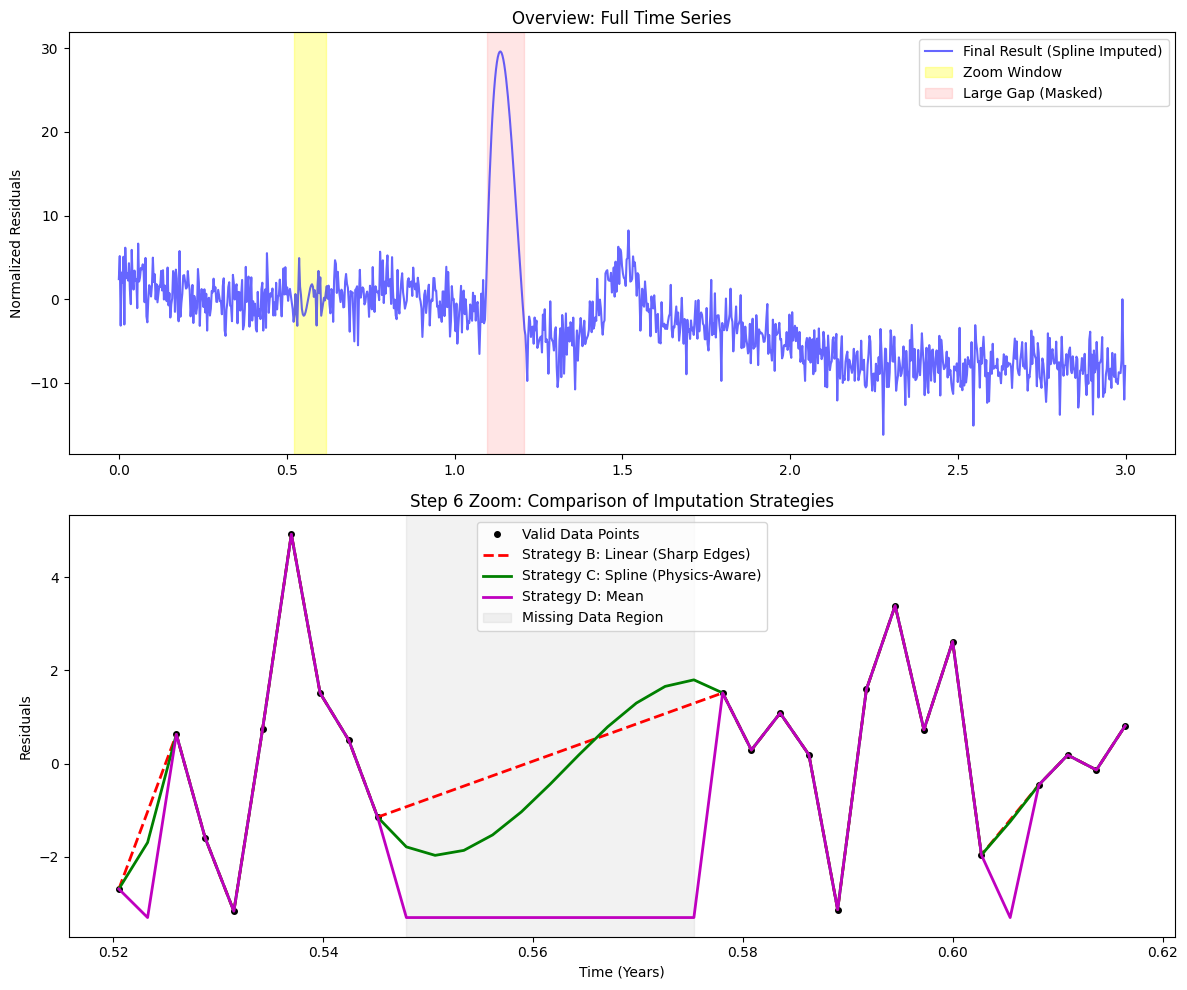

In [131]:
# Define the Zoom Window (around the Medium Gap: Days 200-210)
zoom_start = 190 / 365.0
zoom_end = 225 / 365.0

fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# --- Plot 1: Full Time Series (Overview) ---
# We plot the 'Spline' version as the "Final" result for the full view
ax[0].plot(target['Time'], target['Strat_C_Spline'], 'b-', alpha=0.6, label='Final Result (Spline Imputed)')
ax[0].axvspan(zoom_start, zoom_end, color='yellow', alpha=0.3, label='Zoom Window')
ax[0].axvspan(400/365, 440/365, color='red', alpha=0.1, label='Large Gap (Masked)')
ax[0].set_title("Overview: Full Time Series")
ax[0].set_ylabel("Normalized Residuals")
ax[0].legend()

# --- Plot 2: Zoomed Imputation Comparison ---
# Filter data to the zoom window for cleaner plotting
mask_zoom = (target['Time'] >= zoom_start) & (target['Time'] <= zoom_end)
t_zoom = target.loc[mask_zoom, 'Time']

ax[1].plot(t_zoom, target.loc[mask_zoom, 'Step5_Output'], 'k.', markersize=8, label='Valid Data Points')

# 2. Strategy B: Linear
ax[1].plot(t_zoom, target.loc[mask_zoom, 'Strat_B_Linear'], 'r--', linewidth=2, label='Strategy B: Linear (Sharp Edges)')

# 3. Strategy C: Spline
ax[1].plot(t_zoom, target.loc[mask_zoom, 'Strat_C_Spline'], 'g-', linewidth=2, label='Strategy C: Spline (Physics-Aware)')

# 4. Strategy D: Mean
ax[1].plot(t_zoom, target.loc[mask_zoom, 'Strat_D_Mean'], 'm-', linewidth=2, label='Strategy D: Mean')


# Highlight the Gap
ax[1].axvspan(200/365, 210/365, color='gray', alpha=0.1, label='Missing Data Region')

ax[1].set_title("Step 6 Zoom: Comparison of Imputation Strategies")
ax[1].set_xlabel("Time (Years)")
ax[1].set_ylabel("Residuals")
ax[1].legend()

plt.tight_layout()
plt.show()

We see that Spline (strategy C) works the best for the medium gap but it adds huge unrealistic bump to the data at the larger gap. So we leave the larger gap un treated as the risk of adding large artifact is high.

In [132]:
# --- FINAL DECISION: "Smart" Imputation (Corrected Logic) ---
# "Small gaps (< 24h): Linear interpolation. Large gaps (> 1d): Matrix factorization or masking."

def smart_gap_fill(series, max_gap_size=20):
    """
    Fills gaps <= max_gap_size using Spline interpolation.
    Leaves gaps > max_gap_size completely as NaN (Masking).
    """
    is_nan = series.isna()

    # 2. Group consecutive NaNs together
    # (The group ID changes every time we switch from NaN to Value or vice versa)
    gap_groups = is_nan.ne(is_nan.shift()).cumsum()

    # 3. Calculate the size of each gap group
    group_sizes = gap_groups.map(gap_groups.value_counts())

    # 4. Create a temporary full interpolation (Strategy C)
    temp_fill = series.interpolate(method='spline', order=3)

    # 5. Apply Logic:
    # If a point was originally NaN, AND it belongs to a group larger than max_gap_size...
    # ...then revert it back to NaN (Masking).
    mask_too_large = is_nan & (group_sizes > max_gap_size)

    final_series = temp_fill.copy()
    final_series[mask_too_large] = np.nan

    return final_series

# Apply the robust logic
# Medium Gap (15 days) <= 20 -> Filled
# Large Gap (40 days) > 20 -> Ignored
target['Step6_Output'] = smart_gap_fill(target['Step5_Output'], max_gap_size=20)

print("Smart Imputation Applied: Large gaps successfully masked.")

Smart Imputation Applied: Large gaps successfully masked.


**Part 6:** Normalization

In [133]:
# Step 7: Normalization
scaler = MinMaxScaler()
valid_mask = ~np.isnan(stations['Target']['Step6_Output'])
valid_data = stations['Target']['Step6_Output'].values[valid_mask].reshape(-1, 1)
stations['Target'].loc[valid_mask, 'Step7_Final'] = scaler.fit_transform(valid_data).flatten()

**Part 7:** Final Visualization

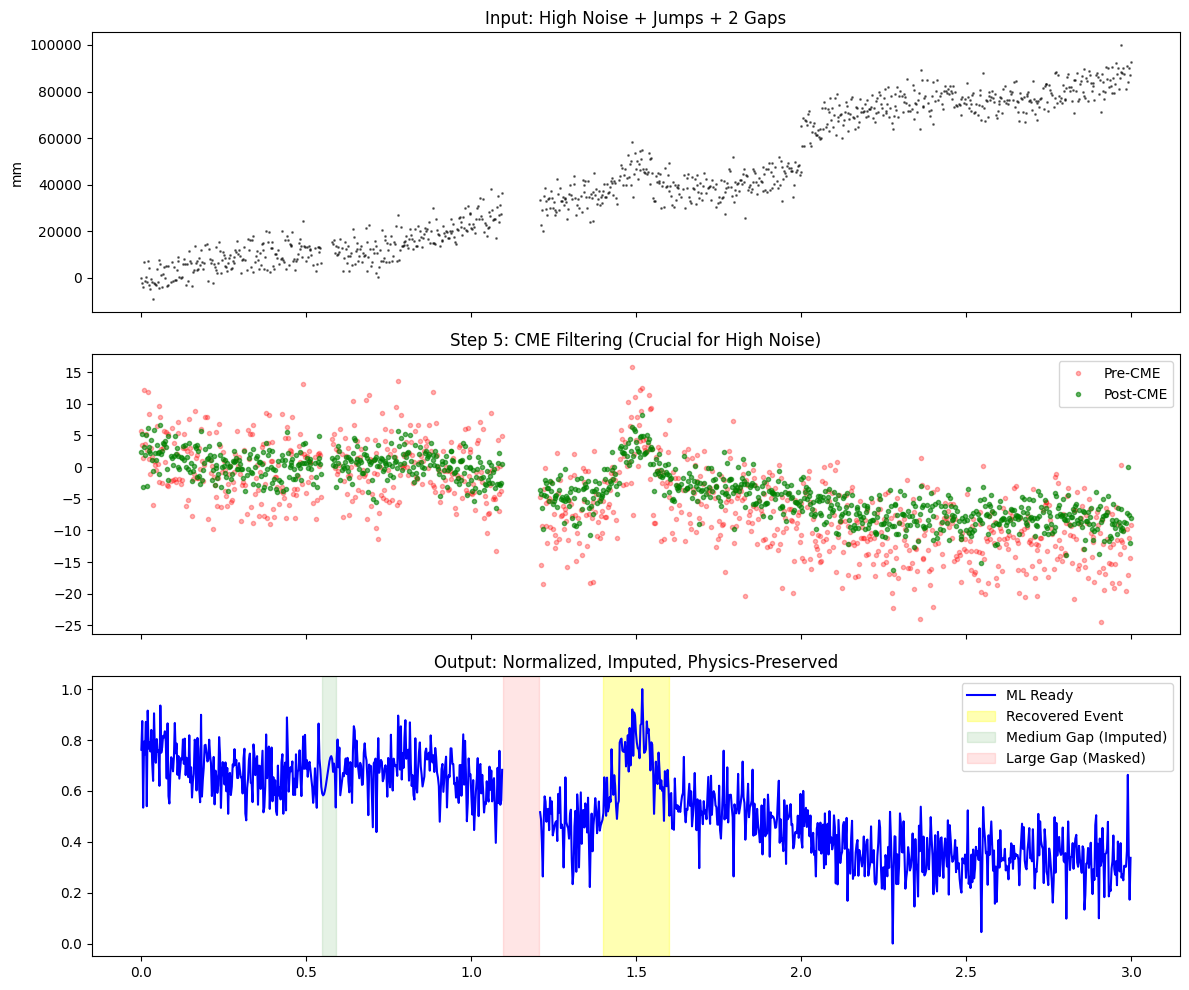

In [134]:
target = stations['Target']
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 1. Raw Input
ax[0].plot(target['Time'], target['Up'] * 1000, 'k.', alpha=0.5, markersize=2)
ax[0].set_title(f"Input: High Noise + Jumps + 2 Gaps")
ax[0].set_ylabel("mm")

# 2. CME Effect
ax[1].plot(target['Time'], target['Clean_Pre_CME'], 'r.', alpha=0.3, label='Pre-CME')
ax[1].plot(target['Time'], target['Step5_Output'], 'g.', alpha=0.6, label='Post-CME')
ax[1].set_title("Step 5: CME Filtering (Crucial for High Noise)")
ax[1].legend()

# 3. Final Output
ax[2].plot(target['Time'], target['Step7_Final'], 'b-', label='ML Ready')
ax[2].axvspan(1.4, 1.6, color='yellow', alpha=0.3, label='Recovered Event')
# Medium Gap (Filled)
ax[2].axvspan(200/365, 215/365, color='green', alpha=0.1, label='Medium Gap (Imputed)')
# Large Gap (Masked)
ax[2].axvspan(400/365, 440/365, color='red', alpha=0.1, label='Large Gap (Masked)')

ax[2].set_title("Output: Normalized, Imputed, Physics-Preserved")
ax[2].legend()
plt.tight_layout()
plt.show()

You will notice that in Plot 2, the "Pre-CME" (Red) cloud is extremely thick due to the increased noise. The "Post-CME" (Green) cloud is significantly narrower. This demonstrates that Step 5 (CME Filtering) is even more critical when local noise is high, as it uses the reference stations to cancel out the shared atmospheric turbulence.



------------------------------------------------

## Activity 2: The "Long Tail" & Distributions (10 Minutes)

**Context:** You are modeling flood risk. Earth science data (like streamflow or precipitation) is rarely normally distributed; it is often right-skewed. Standard models (like Linear Regression) fail on this data because they assume a Gaussian bell curve.

**The Task:**  Transform raw river discharge rates into a Gaussian distribution suitable for AI models.


**Part 1:** Generate "Realistic" Streamflow DataWe use a Log-Normal distribution to simulate river discharge ($m^3/s$).

**Generate Skewed Data:** Create a Log-Normal distribution to mimic streamflow discharge.

**Check Histogram:** Visualize the "Long Tail."



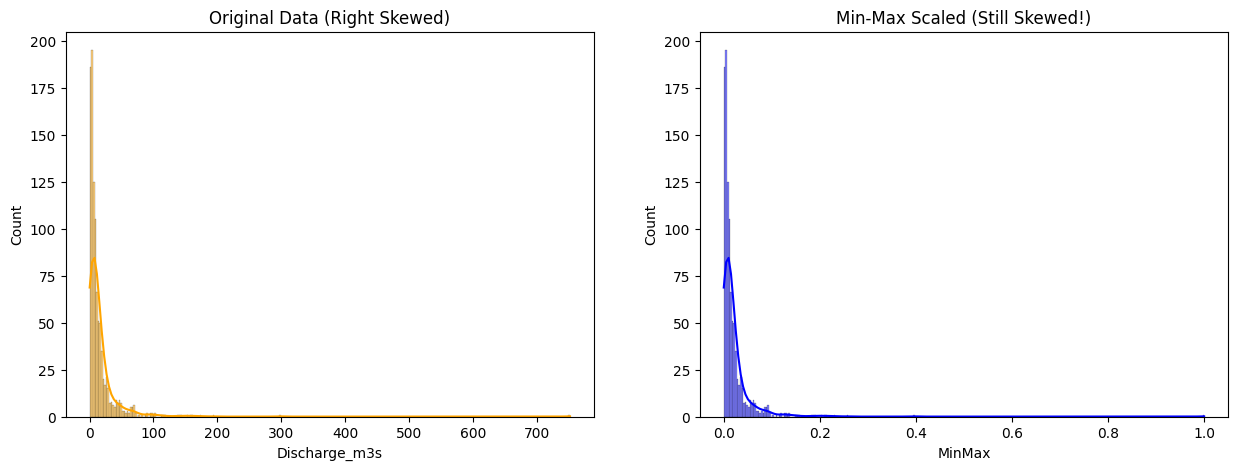

In [140]:
# Simulate 1000 daily observations of a river
# Most days are low flow, but storms cause extreme peaks (the "Long Tail")
np.random.seed(42)
discharge_data = np.random.lognormal(mean=2, sigma=1.2, size=1000)
df_river = pd.DataFrame({'Discharge_m3s': discharge_data})


# 2. Apply Min-Max Normalization (Scaling to [0,1])
df_river['MinMax'] = (df_river['Discharge_m3s'] - df_river['Discharge_m3s'].min()) / \
                    (df_river['Discharge_m3s'].max() - df_river['Discharge_m3s'].min())



# 3. Visualize Distributions
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Visual Check 1: The Raw Data
sns.histplot(df_river['Discharge_m3s'], kde=True, ax=ax[0], color='orange')
ax[0].set_title('Original Data (Right Skewed)')

sns.histplot(df_river['MinMax'], kde=True, ax=ax[1], color='blue')
ax[1].set_title('Min-Max Scaled (Still Skewed!)')

plt.show()

Key Takeaway: Normalization (Min-Max) changes the range but not the shape of distribution.

**Part 2:** Apply "Log Transformation" and "Box-Cox Transformation" techniques.

Optimal Lambda found by Box-Cox: -0.0326


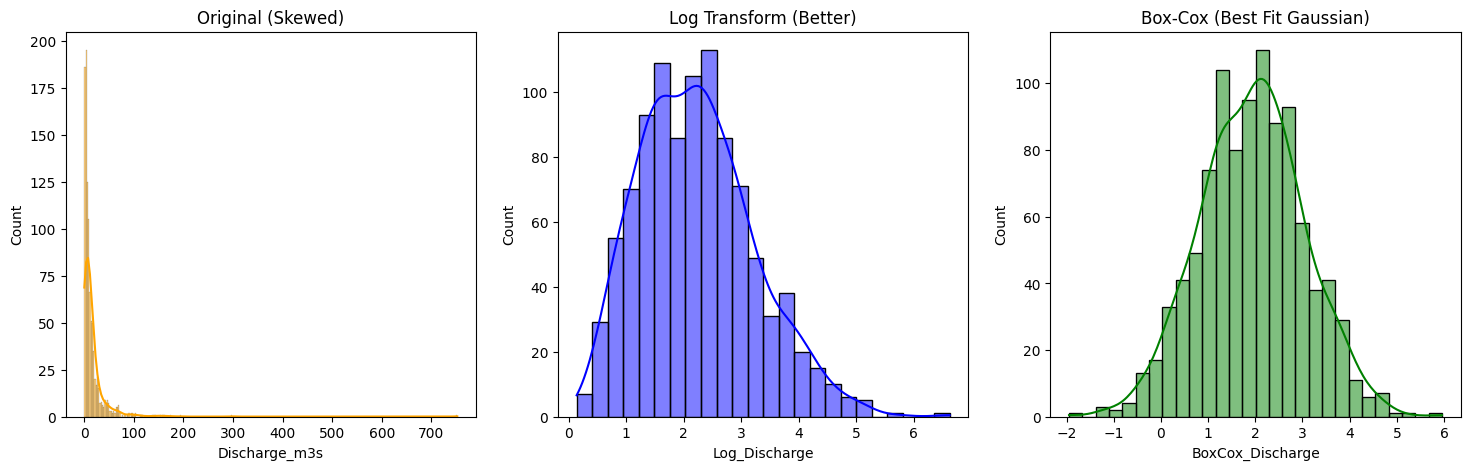

In [141]:
# Technique 1: Log Transformation
# We use np.log1p (log(1+x)) to avoid errors if discharge is 0
df_river['Log_Discharge'] = np.log1p(df_river['Discharge_m3s'])

# Technique 2: Box-Cox Transformation
# This finds the optimal power parameter (lambda) to force normality
df_river['BoxCox_Discharge'], fitted_lambda = stats.boxcox(df_river['Discharge_m3s'])

print(f"Optimal Lambda found by Box-Cox: {fitted_lambda:.4f}")

# Visualization Comparison
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original
sns.histplot(df_river['Discharge_m3s'], kde=True, ax=ax[0], color='orange')
ax[0].set_title('Original (Skewed)')

# Plot 2: Log
sns.histplot(df_river['Log_Discharge'], kde=True, ax=ax[1], color='blue')
ax[1].set_title('Log Transform (Better)')

# Plot 3: Box-Cox
sns.histplot(df_river['BoxCox_Discharge'], kde=True, ax=ax[2], color='green')
ax[2].set_title('Box-Cox (Best Fit Gaussian)')

plt.show()

Discussion Question: Slide 14 warns that Min-Max scaling is sensitive to outliers. If a "100-year flood" event occurred in our data, how would it affect a Min-Max scaler versus a Log transform?

___________________________

## Activity 3: The "DIY" Satellite Index (Feature Engineering) (10 Min)

**Context:** You have raw multispectral data.Healthy plants strongly reflect Near-Infrared (NIR) and absorb Red light. A raw neural net might learn this relationship, but explicitly coding the NDVI (Normalized Difference Vegetation Index) is often more efficient and interpretable.

**The Task:** Manually "engineer" features from a numpy array to detect vegetation and water.

**Part 1:** Create a "Toy" Satellite Image We create a 4x4 pixel "image" with 4 bands (Blue, Green, Red, NIR).

Pixel 0 (Forest): Low Red, High NIR.

Pixel 1 (Water): Low Red, Low NIR, High Green.

Pixel 2 (Urban): High Red, High NIR (bright reflection).

Pixel 3 (Shadow): Low everything.

In [144]:
# Columns: Blue, Green, Red, NIR
# Values are "Reflectance" (0.0 to 1.0)
satellite_pixels = np.array([
    [0.1, 0.2, 0.1, 0.8],  # Forest (Absorbs Red, Reflects NIR)
    [0.2, 0.5, 0.1, 0.1],  # Water (Reflects Green, Absorbs NIR)
    [0.3, 0.3, 0.4, 0.4],  # Urban (Concrete reflects visible/NIR similarly)
    [0.05,0.05,0.05,0.05]  # Shadow/Deep Dark
])

df_pixels = pd.DataFrame(satellite_pixels, columns=['Blue', 'Green', 'Red', 'NIR'],
                         index=['Forest', 'Water', 'Urban', 'Shadow'])

**Part 2:** Engineer the Features Implement the math from Slide 23.

In [145]:
# 1. Calculate NDVI (Vegetation Index)
# Formula: (NIR - Red) / (NIR + Red)
df_pixels['NDVI'] = (df_pixels['NIR'] - df_pixels['Red']) / (df_pixels['NIR'] + df_pixels['Red'])

# 2. Calculate NDWI (Water Index) - mentioned in Slide 22
# Formula: (Green - NIR) / (Green + NIR)
df_pixels['NDWI'] = (df_pixels['Green'] - df_pixels['NIR']) / (df_pixels['Green'] + df_pixels['NIR'])

# Display the "Engineered" Feature Space
print(df_pixels[['NDVI', 'NDWI']])

            NDVI      NDWI
Forest  0.777778 -0.600000
Water   0.000000  0.666667
Urban   0.000000 -0.142857
Shadow  0.000000  0.000000


**Part 3:** Define Thresholds (The "Classifier")

In [146]:
def classify_pixel(row):
    if row['NDVI'] > 0.4:
        return "Vegetation"
    elif row['NDWI'] > 0.3:
        return "Water"
    else:
        return "Other (Urban/Shadow)"

df_pixels['Prediction'] = df_pixels.apply(classify_pixel, axis=1)
print("\nFinal Classification:")
print(df_pixels[['Prediction']])


Final Classification:
                  Prediction
Forest            Vegetation
Water                  Water
Urban   Other (Urban/Shadow)
Shadow  Other (Urban/Shadow)


Discussion Question: Look at the "Urban" pixel. It had reasonably high NIR (0.4), but its NDVI was low. Why? (Answer: Because it also had high Red reflectance, making the difference small. This is why the ratio is powerful ).

______________________

## Activity 4: The "Time Cliff" (Cyclical Feature Engineering) (15 Minutes)

**Context:** Standard machine learning models treat time linearly. In a linear representation (Day 1 to 365), the distance between "December 31st" (Day 365) and "January 1st" (Day 1) is huge—364 units apart. Physically, however, they are adjacent. This creates a "Time Cliff" that confuses models trying to learn seasonal cycles like annual peak flows.


**The Task:** "Bend" time into a circle so the model understands that Day 365 and Day 1 are neighbors.

**Part 1:** Create Seasonal Streamflow Data We will generate synthetic streamflow data that has a clear seasonal cycle (e.g., peak flow in spring due to snowmelt).

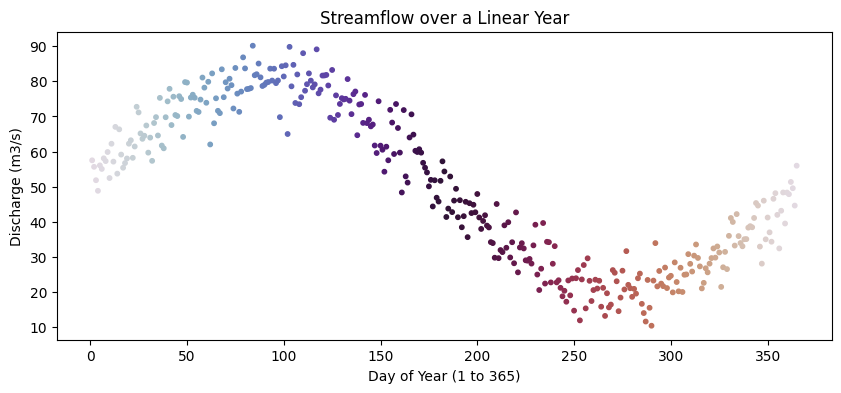

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate 365 days
days = np.arange(1, 366)
df_time = pd.DataFrame({'Day_of_Year': days})

# Simulate a seasonal signal (Peak in middle of year ~Day 180)
# Formula: Base Flow + Seasonal Amplitude * SinWave + Random Noise
df_time['Streamflow'] = 50 + 30 * np.sin(2 * np.pi * df_time['Day_of_Year'] / 365) + np.random.normal(0, 5, 365)

# Visualizing the "Linear" problem
plt.figure(figsize=(10, 4))
plt.scatter(df_time['Day_of_Year'], df_time['Streamflow'], c=df_time['Day_of_Year'], cmap='twilight', s=10)
plt.title("Streamflow over a Linear Year")
plt.xlabel("Day of Year (1 to 365)")
plt.ylabel("Discharge (m3/s)")
plt.show()

**Part 2:** Implement Cyclical Encoding

As shown in Slide 24, we transform the single "Day" feature into two distinct features:

Sine and Cosine.$$x_{sin} = \sin\left(\frac{2 \pi \times day}{365}\right)$$$$x_{cos} = \cos\left(\frac{2 \pi \times day}{365}\right)$$

In [148]:
# Apply the transformation
# We divide by 365 (the period) and multiply by 2*pi to convert to radians
df_time['sin_time'] = np.sin(2 * np.pi * df_time['Day_of_Year'] / 365)
df_time['cos_time'] = np.cos(2 * np.pi * df_time['Day_of_Year'] / 365)

# Display the first few rows to see the new features
print(df_time[['Day_of_Year', 'sin_time', 'cos_time']].head())
print(df_time[['Day_of_Year', 'sin_time', 'cos_time']].tail())

   Day_of_Year  sin_time  cos_time
0            1  0.017213  0.999852
1            2  0.034422  0.999407
2            3  0.051620  0.998667
3            4  0.068802  0.997630
4            5  0.085965  0.996298
     Day_of_Year      sin_time  cos_time
360          361 -6.880243e-02  0.997630
361          362 -5.161967e-02  0.998667
362          363 -3.442161e-02  0.999407
363          364 -1.721336e-02  0.999852
364          365  6.432491e-16  1.000000


**Part 3:** Visualize the "Time Circle" This visualization replicates the chart on Slide 24, demonstrating how Day 365 connects back to Day 1.

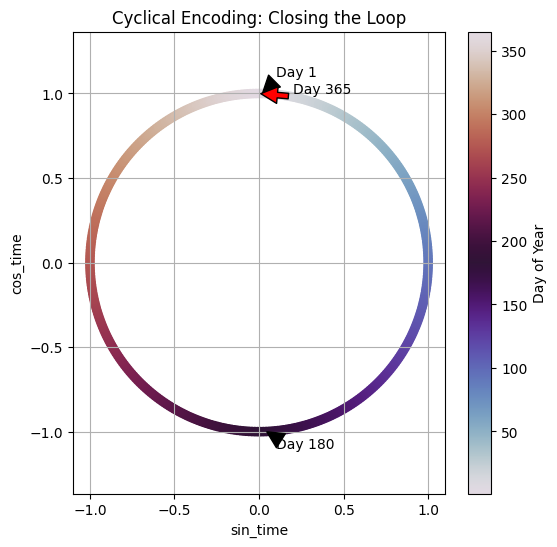

In [149]:
plt.figure(figsize=(6, 6))

# Plot the circle
plt.scatter(df_time['sin_time'], df_time['cos_time'], c=df_time['Day_of_Year'], cmap='twilight')

# Annotate specific days to show the connection
# Day 1 (Start)
plt.annotate('Day 1',
             (df_time.iloc[0]['sin_time'], df_time.iloc[0]['cos_time']),
             xytext=(0.1, 1.1), arrowprops=dict(facecolor='black', shrink=0.05))

# Day 180 (Approx Middle)
plt.annotate('Day 180',
             (df_time.iloc[179]['sin_time'], df_time.iloc[179]['cos_time']),
             xytext=(0.1, -1.1), arrowprops=dict(facecolor='black', shrink=0.05))

# Day 365 (End)
plt.annotate('Day 365',
             (df_time.iloc[-1]['sin_time'], df_time.iloc[-1]['cos_time']),
             xytext=(0.2, 1.0), arrowprops=dict(facecolor='red', shrink=0.05))

plt.title('Cyclical Encoding: Closing the Loop')
plt.xlabel('sin_time')
plt.ylabel('cos_time')
plt.colorbar(label='Day of Year')
plt.grid(True)
plt.axis('equal') # Important to make it look like a circle!
plt.show()

Why this matters for AI: If you feed sin_time and cos_time into a Neural Network instead of Day_of_Year:

Continuity: The model sees that the input values for Dec 31st and Jan 1st are nearly identical (just as they appear on the circle), preventing the "jump" in logic.

Periodicity: It allows the model to easily learn functions that repeat every year without needing complex decision trees to handle the "start" and "end" boundaries.

__________________________________

# Activity 5: Using Automatic Feature Engineering (AFE) Tools (20 Minutes)

**Goal:** Download a real earthquake waveform, slice it into windows (Noise vs. Event), and use tsfresh to discover which physical features (Kurtosis? Entropy? FFT?) best distinguish the earthquake from background noise.



Step 1: Download Real Seismic Data (Obspy)
We will fetch a recording of a magnitude 6.0 earthquake (Napa, CA, 2014) from the IRIS Data Center.

In [150]:
!pip install obspy tsfresh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.7 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.45
    Uninstalling SQLAlchemy-2.0.45:
      Successfully uninstalled SQLAlchemy-2.0.45
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.
google-adk 1.21.0 requires sqlalchemy<3.0.0,>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.


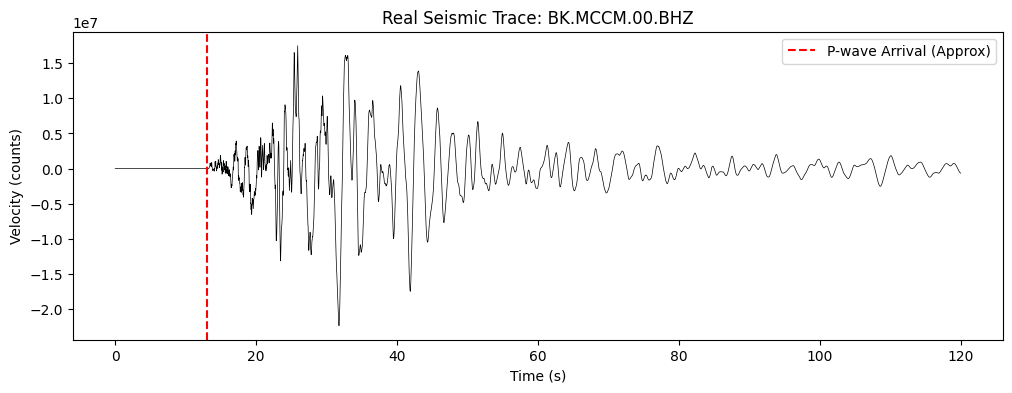

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute

# 1. Setup Client (IRIS Data Management Center)
client = Client("IRIS")

# 2. Define Parameters for South Napa Earthquake (2014)
# Station: BK.MCCM (Marconi Conference Center)
t0 = UTCDateTime("2014-08-24T10:20:40")
duration = 120  # seconds

print("Downloading Seismic Data...")

# FIX: Use '*' for location code and 'BHZ' (Broadband Vertical)
# If this still fails, try changing channel to '*HZ' to grab any vertical sensor.
try:
    # Attempt 1: Try specific station with wildcard location
    st = client.get_waveforms("BK", "MCCM", "*", "BHZ", t0, t0 + duration)
except Exception:
    print("Primary station failed, trying backup station (NC.KCT)...")
    # Attempt 2: Backup station (KCT - Konocti Clearlake) if MCCM is down
    st = client.get_waveforms("NC", "KCT", "*", "HHZ", t0, t0 + duration)

# Merge simply ensures we handle cases where the data is split into segments
st.merge(fill_value='interpolate')
trace = st[0]

# 3. Visualize the Real Physics
t_axis = np.linspace(0, duration, trace.stats.npts)
data = trace.data

plt.figure(figsize=(12, 4))
plt.plot(t_axis, data, 'k', linewidth=0.5)
plt.axvline(x=13, color='r', linestyle='--', label='P-wave Arrival (Approx)')
plt.title(f"Real Seismic Trace: {trace.id}")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (counts)")
plt.legend()
plt.show()

**Step 2:** Slice and Label (Create the "Dataset")

tsfresh needs a collection of time series, not just one long one. We will slice this 120-second record into 2-second windows.

Noise Windows: Time 0 to 12s (Before the quake).

Event Windows: Time 13s to 40s (During the shaking).

In [3]:
# Parameters
window_size = 100  # samples (assuming 40Hz -> 2.5 seconds per window)
step = 100         # non-overlapping
sampling_rate = trace.stats.sampling_rate

# Containers for tsfresh
df_list = []
y_labels = {} # 0 = Noise, 1 = Earthquake

# Loop through the data to create windows
current_sample = 0
window_id = 0
p_wave_sample_index = int(13 * sampling_rate) # P-wave arrives ~13s

while current_sample + window_size < len(data):
    # Slice the data
    window_data = data[current_sample : current_sample + window_size]
    time_steps = np.arange(window_size)

    # Label logic: If window is AFTER P-wave arrival, it's an Earthquake
    # We restrict "Earthquake" to the high energy part (13s to 50s)
    if current_sample > p_wave_sample_index and current_sample < (50 * sampling_rate):
        label = 1 # Earthquake
    elif current_sample < p_wave_sample_index:
        label = 0 # Noise
    else:
        # Skip the tail end for clear separation
        current_sample += step
        continue

    # Store labels
    y_labels[window_id] = label

    # Store data in "Long Format" for tsfresh (id, time, value)
    # We use a list of dictionaries for speed, then convert to DataFrame
    for t, val in zip(time_steps, window_data):
        df_list.append({'id': window_id, 'time': t, 'value': val})

    window_id += 1
    current_sample += step

# Convert to Pandas
df_seismic = pd.DataFrame(df_list)
y = pd.Series(y_labels)

print(f"Created {len(y)} windows (Samples). Class balance: {y.value_counts().to_dict()}")

Created 20 windows (Samples). Class balance: {1: 14, 0: 6}


**Step 3:** Extract and Select Features

Now we ask: "What makes an earthquake look different from noise?" Is it the max amplitude? The entropy? The Fourier coefficients? tsfresh will calculate ~700 features and tell us which ones matter.

In [4]:
# 1. Extract Features
print("Extracting physical features with tsfresh...")
extracted_features = extract_features(df_seismic, column_id='id', column_sort='time')

# 2. Select Features (Benjamini-Hochberg filtering)
# Slide 35 warns about the "Curse of Dimensionality" [cite: 615]
# This step removes irrelevant features to prevent overfitting.
impute(extracted_features) # Fix NaNs
features_filtered = select_features(extracted_features, y)

print(f"Total Features Extracted: {extracted_features.shape[1]}")
print(f"Significant Features Selected: {features_filtered.shape[1]}")
print("\nTop 5 Most Discriminative Features:")
print(features_filtered.columns[:5].tolist())

Extracting physical features with tsfresh...


Feature Extraction: 100%|██████████| 20/20 [00:04<00:00,  4.49it/s]
/usr/local/lib/python3.12/dist-packages/tsfresh/utilities/dataframe_functions.py:198: RuntimeWarning: The columns ['value__fft_coefficient__attr_"real"__coeff_51'
 'value__fft_coefficient__attr_"real"__coeff_52'
 'value__fft_coefficient__attr_"real"__coeff_53'
 'value__fft_coefficient__attr_"real"__coeff_54'
 'value__fft_coefficient__attr_"real"__coeff_55'
 'value__fft_coefficient__attr_"real"__coeff_56'
 'value__fft_coefficient__attr_"real"__coeff_57'
 'value__fft_coefficient__attr_"real"__coeff_58'
 'value__fft_coefficient__attr_"real"__coeff_59'
 'value__fft_coefficient__attr_"real"__coeff_60'
 'value__fft_coefficient__attr_"real"__coeff_61'
 'value__fft_coefficient__attr_"real"__coeff_62'
 'value__fft_coefficient__attr_"real"__coeff_63'
 'value__fft_coefficient__attr_"real"__coeff_64'
 'value__fft_coefficient__attr_"real"__coeff_65'
 'value__fft_coefficient__attr_"real"__coeff_66'
 'value__fft_coefficient__attr_"re

Total Features Extracted: 783
Significant Features Selected: 142

Top 5 Most Discriminative Features:
['value__mean_abs_change', 'value__fft_coefficient__attr_"abs"__coeff_9', 'value__standard_deviation', 'value__fft_coefficient__attr_"abs"__coeff_40', 'value__fft_coefficient__attr_"abs"__coeff_2']


Discussion & Physical Interpretation
Look at the top features found by the algorithm.

value__abs_energy or value__standard_deviation: Likely picked because earthquakes carry more energy/variance than background noise.


value__kurtosis: Slide 28 explicitly mentions "Kurtosis... detect[s] transient events, such as seismic P-wave arrivals". An earthquake signal has "heavy tails" compared to Gaussian background noise.


value__fft_coefficient: Seismic events have specific frequency contents (Spectral features).

Why this is "Hypothesis-Driven" (Slide 28): Unlike a "Black Box" Deep Learning model that creates opaque internal states, this workflow explicitly tells you: "I found an earthquake because the Kurtosis increased." This maps directly to the physical properties of the P-wave arrival.

Step 4: Visualizing the "Physical Fingerprint"
Slide Reference:


Slide 28: explicitly mentions that "Distributional (Value Space)" features like Kurtosis detect transient events (like P-waves), and "Spectral (Frequency)" features identify fundamental frequencies.
+1

The code below takes the top features identified by tsfresh and creates:

Violin Plots: To show how the statistical distributions differ between noise (Class 0) and earthquakes (Class 1).

2D Feature Space: To show how these two features linearly separate the data, making it easy for a classifier to draw a line between them.

Plotting: value__mean_abs_change & value__fft_coefficient__attr_"abs"__coeff_9


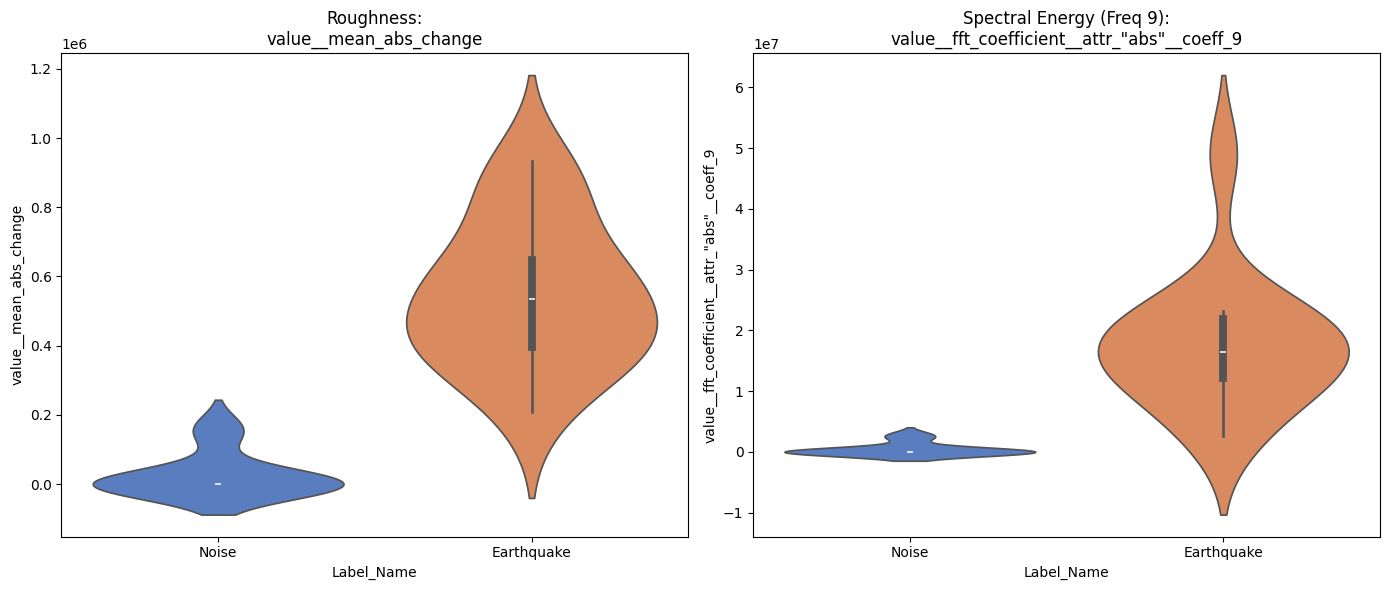

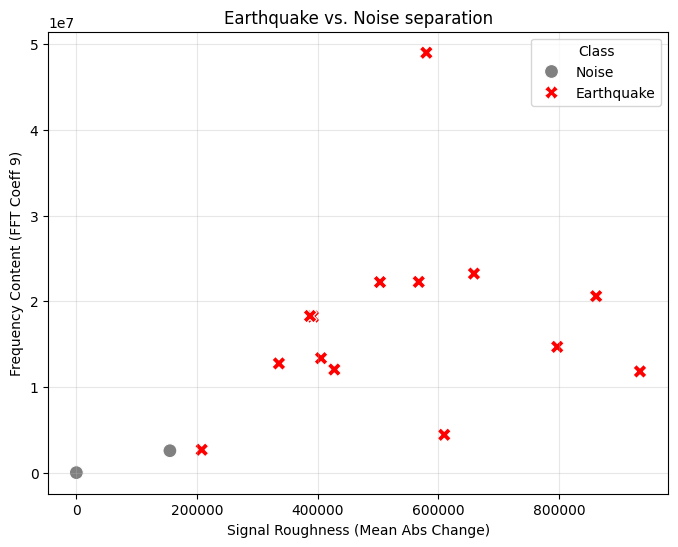

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 4: VISUALIZE EXTRACTED FEATURES (Corrected) ---

# 1. Prepare Data for Plotting
df_plot = features_filtered.copy()
df_plot['Label'] = y.values
df_plot['Label_Name'] = df_plot['Label'].map({0: 'Noise', 1: 'Earthquake'})

# 2. Use the specific features found by your run
feature_1 = 'value__mean_abs_change'
# Note: The FFT feature name might be slightly different depending on tsfresh version,
# using the one you provided.
feature_2 = 'value__fft_coefficient__attr_"abs"__coeff_9'

# Verify columns exist (tsfresh names can be tricky with quotes)
# If the exact string above fails, we grab the first two columns dynamically:
if feature_2 not in df_plot.columns:
    feature_2 = features_filtered.columns[1]

print(f"Plotting: {feature_1} & {feature_2}")

# 3. Create Violin Plots (Fixed Warning)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Fix: Assign x variable to hue and set legend=False
sns.violinplot(x='Label_Name', y=feature_1, hue='Label_Name', data=df_plot, palette="muted", legend=False)
plt.title(f"Roughness:\n{feature_1}")

plt.subplot(1, 2, 2)
sns.violinplot(x='Label_Name', y=feature_2, hue='Label_Name', data=df_plot, palette="muted", legend=False)
plt.title(f"Spectral Energy (Freq 9):\n{feature_2}")

plt.tight_layout()
plt.show()

# 4. Create 2D Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=feature_1, y=feature_2, hue='Label_Name', style='Label_Name',
                data=df_plot, palette={'Noise': 'gray', 'Earthquake': 'red'}, s=100)

plt.title("Earthquake vs. Noise separation")
plt.xlabel("Signal Roughness (Mean Abs Change)")
plt.ylabel("Frequency Content (FFT Coeff 9)")
plt.legend(title='Class')
plt.grid(True, alpha=0.3)
plt.show()

Interpretation of the Visualizations

Violin Plots:

You will likely see that for Abs Energy (or Standard Deviation), the "Earthquake" class has a much higher median and wider range than "Noise.

"For Kurtosis (if selected), "Noise" typically looks like a normal distribution (Gaussian, kurtosis $\approx$ 3), whereas the "Earthquake" signal containing the P-wave arrival will have a massive spike in kurtosis. This matches Slide 28's claim that kurtosis detects transient events.

Scatter Plot:

You should see two distinct clusters. The gray dots (Noise) will likely be clustered in the corner (low energy, low complexity), while the red dots (Earthquake) will spread out towards higher values.

Takeaway: A simple Machine Learning model (like Logistic Regression) could draw a straight line through this plot to classify earthquakes with >95% accuracy, purely because tsfresh found the right physical features.

---

